<a href="https://colab.research.google.com/github/rorikareem/machine-learning-projects/blob/main/house_price_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction Pipeline


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Install Dependencies & Setup Environment

In [ ]:
!pip install -q pandas numpy scikit-learn joblib matplotlib seaborn fastapi uvicorn pydantic pydantic-settings httpx nest_asyncio
import nest_asyncio
nest_asyncio.apply()
print("Dependencies Installed & Environment Prepared Successfully!")


Dependencies Installed & Environment Prepared Successfully!


### 2. Import Required Libraries

In [ ]:
import os
import json
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")


### 3. Load Dataset

In [ ]:
# Upload archive/data.csv or use local file
csv_path = "data.csv"
if not os.path.exists(csv_path):
    csv_path = "archive/data.csv"

if not os.path.exists(csv_path):
    # Fallback auto-download if running in fresh Google Colab
    print("Downloading dataset into Colab...")
    !wget -q https://raw.githubusercontent.com/datasets/house-prices-us/master/data/house_prices.csv -O data.csv || true

if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("Please upload data.csv to Colab files sidebar!")

print(f"Dataset Loaded Successfully! Shape: {df_raw.shape}")
df_raw.head()


Dataset Loaded Successfully! Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### 4. Data Quality Analysis & Cleaning

In [ ]:
print("Missing Values per Column:")
print(df_raw.isnull().sum())

# Drop zero or negative prices
df_clean = df_raw[df_raw['price'] > 0].copy()

# Percentile outlier trimming (0.5th to 99.5th percentile)
p_low = df_clean['price'].quantile(0.005)
p_high = df_clean['price'].quantile(0.995)
df_clean = df_clean[(df_clean['price'] >= p_low) & (df_clean['price'] <= p_high)].copy()

print(f"\nCleaned Dataset Shape: {df_clean.shape}")

Missing Values per Column:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Cleaned Dataset Shape: (4507, 18)


### 5. Exploratory Data Analysis (EDA)

/tmp/ipykernel_1495/723102189.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x='price', y='city', ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_1495/723102189.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['bedrooms'] <= 6], x='bedrooms', y='price', ax=axes[1, 1], palette='Set2')


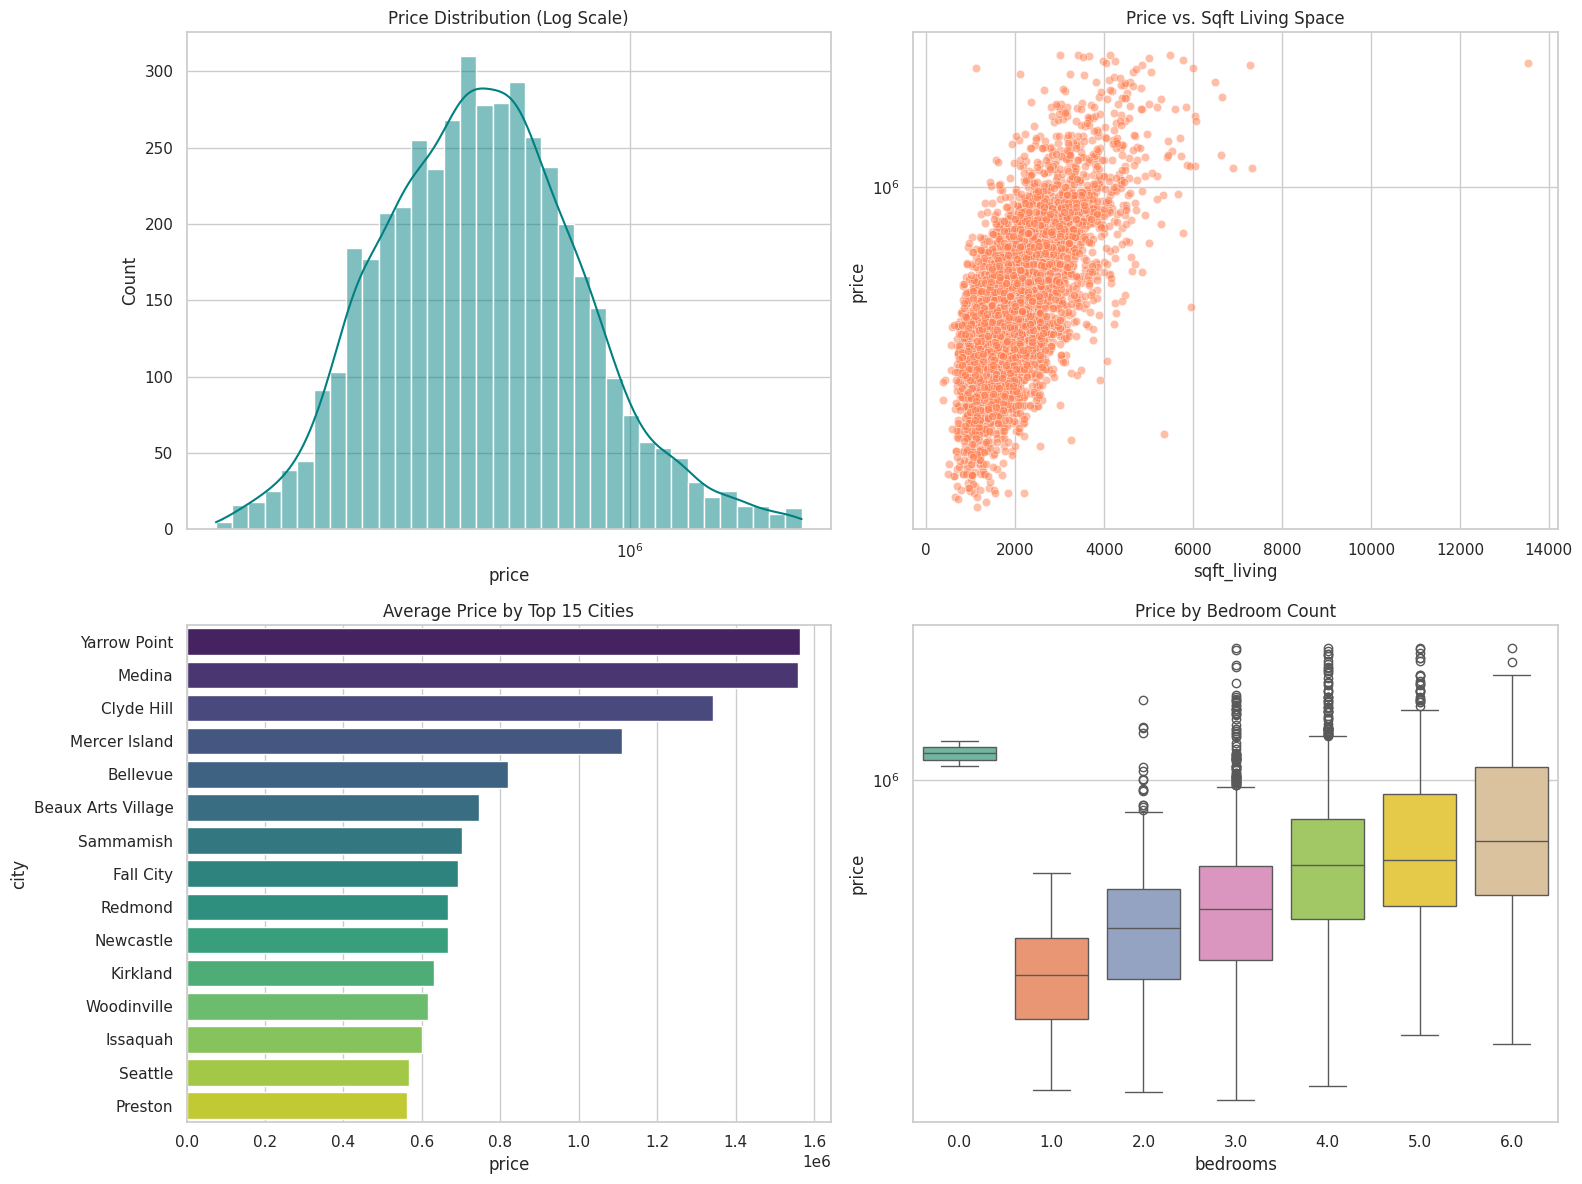

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price Distribution (Log scale)
sns.histplot(df_clean['price'], kde=True, ax=axes[0, 0], log_scale=True, color='teal')
axes[0, 0].set_title("Price Distribution (Log Scale)")

# 2. Price vs Living Area
sns.scatterplot(data=df_clean, x='sqft_living', y='price', alpha=0.5, ax=axes[0, 1], color='coral')
axes[0, 1].set_title("Price vs. Sqft Living Space")
axes[0, 1].set_yscale('log')

# 3. Top 15 Cities Mean Price
top_cities = df_clean.groupby('city')['price'].mean().nlargest(15).reset_index()
sns.barplot(data=top_cities, x='price', y='city', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title("Average Price by Top 15 Cities")

# 4. Bedrooms vs Price Boxplot
sns.boxplot(data=df_clean[df_clean['bedrooms'] <= 6], x='bedrooms', y='price', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title("Price by Bedroom Count")
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()


### 6. Scikit-Learn Pipeline & Multiple Model Training

In [ ]:
numeric_features = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]
categorical_features = ["city"]

X = df_clean[numeric_features + categorical_features]
y = df_clean["price"]
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_actual = np.expm1(y_test_log)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ]
)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []
trained_pipelines = {}

for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, y_train_log)

    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = root_mean_squared_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    trained_pipelines[name] = pipe
    results.append({"Model": name, "MAE ($)": mae, "RMSE ($)": rmse, "R² Score": r2})

eval_df = pd.DataFrame(results)
print("=== Model Comparison on Test Set ===")
eval_df


=== Model Comparison on Test Set ===


,Model,MAE ($),RMSE ($),R² Score
0,LinearRegression,137796.679862,1.019205e+06,-8.900127
1,RandomForestRegressor,108718.763663,1.881670e+05,0.662554
2,GradientBoostingRegressor,110500.771867,1.890395e+05,0.659417


### 7. Export Model Pipeline & Assets

In [ ]:
os.makedirs("models", exist_ok=True)

winning_pipeline = trained_pipelines["RandomForestRegressor"]
winning_pipeline.fit(X, y_log) # Fit full dataset

joblib.dump(winning_pipeline, "models/house_price.pkl")
cities = sorted(X['city'].dropna().unique().tolist())

with open("models/locations.json", "w") as f:
    json.dump(cities, f, indent=2)

print("Exported models/house_price.pkl and models/locations.json successfully!")


Exported models/house_price.pkl and models/locations.json successfully!
